# Kritische Prüfung des Verfahrens

Dieses Notebook ist bewusst gegen das eigene Verfahren geschrieben. Es beantwortet
sechs Fragen, und zwar nicht durch Behauptungen, sondern durch Rechnungen, die
schiefgehen *könnten*.

**Warum es dieses Notebook gibt.** Beim Companion-Tensor ist genau der Fehler
passiert, den man hier vermeiden muss: Die Genauigkeit wurde gegen eine zweite
Implementierung **derselben Logik** gemessen statt gegen den exakten Solver. Beide
Implementierungen machten denselben Fehler, also stimmten sie hervorragend
überein — und die Näherung sah gut aus, obwohl sie es nicht war. Erst der
Vergleich gegen `qutip.HEOMSolver` hat gezeigt, dass $K=25$ bei 100 Schritten nur
$5{,}6\times10^{-3}$ liefert.

Daraus folgen zwei Regeln für dieses Notebook:

1. **Jede Zahl wird gegen `qutip.HEOMSolver` gemessen**, nie gegen eine eigene
   Referenz.
2. **Auch der Maßstab wird geprüft.** Denn dieselbe Falle lauert eine Ebene
   höher: Wenn `qutip.HEOMSolver` bei der gewählten Hierarchietiefe selbst nicht
   konvergiert ist, dann heißt „Übereinstimmung auf $10^{-7}$" nur, dass wir
   dieselbe Näherung sehr genau reproduzieren. Prüfung 1 misst diesen Abstand.

Am Ende steht ein Abschnitt, in dem ich die Schwächen aufliste, die ich als
Gutachter bemängeln würde — inklusive derjenigen, die das Verfahren in seiner
jetzigen Form für einen praktischen Einsatz disqualifizieren.

In [1]:
import os, sys, time, warnings
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

from heom_gauge import (build_grid, regrid, qutip_reference, reference_trajectory,
                        make_solver, heom_generator, post_selection_curve,
                        safe_norm2, dilate)
from gauge_circuit import build_circuit, run_grid, run_grid_final

_C_CM = 2.99792458e10
FS_TO_CM = 1e-15 * 2 * np.pi * _C_CM
KB_CM = 0.6950348004

N = 4
H_FMO = np.array([[12375.0, -87.7,   5.5,  -5.9],
                  [-87.7, 12495.0,  30.8,   8.2],
                  [5.5,      30.8, 12175.0, -53.4],
                  [-5.9,      8.2, -53.4, 12285.0]])
H_FMO = H_FMO - np.trace(H_FMO) / N * np.eye(N)
MODEL = dict(H=H_FMO, lam=3.0, gamma=50.0, T_K=300.0, KB_CM=KB_CM, FS_TO_CM=FS_TO_CM)

rho0       = np.diag([1.0, 0.0, 0.0, 0.0])
dt_fs      = 10.0
HEOM_depth = 3
N_STEPS    = 100
DELTA      = 0.02
M_KRYLOV   = 128
t_fs       = np.arange(N_STEPS + 1) * dt_fs
cols       = plt.cm.tab10(np.arange(N))

t0 = time.time()
grid = build_grid(dt_fs, rho0=rho0, delta=DELTA, m=M_KRYLOV, depth=HEOM_depth, **MODEL)
T_BUILD = time.time() - t0
print(f"\nAufbau des Gitters: {T_BUILD:.1f} s")

t0 = time.time()
pops_qutip = qutip_reference(t_fs, rho0=rho0, depth=HEOM_depth, **MODEL)
T_QUTIP = time.time() - t0
print(f"qutip HEOMSolver (100 Schritte): {T_QUTIP:.2f} s")

  A: 2640 x 2640 (165 ADOs)


  gauge delta=0.02 cm^-1: cond(W)=1.74e+10, ||P||=32.3922 -> ||P~||=1.000038 (bound 1.000038)


  Krylov m=128 -> 8 qubits, ||H_m||=1.000038, s=1.000038, s^100=1.0038



Aufbau des Gitters: 258.3 s
10.0%. Run time:   0.03s. Est. time left: 00:00:00:00


20.0%. Run time:   0.05s. Est. time left: 00:00:00:00


...

70.0%. Run time:   0.17s. Est. time left: 00:00:00:00


80.0%. Run time:   0.19s. Est. time left: 00:00:00:00


90.0%. Run time:   0.21s. Est. time left: 00:00:00:00


100.0%. Run time:   0.22s. Est. time left: 00:00:00:00


Total run time:   0.22s
qutip HEOMSolver (100 Schritte): 0.27 s


---
## Prüfung 1 — Ist der Maßstab selbst vertrauenswürdig?

Das ist die tiefste der sechs Fragen. Alle Genauigkeitsangaben lauten „Abweichung
von `qutip.HEOMSolver` bei Tiefe 3 und $N_k=1$". Zwei Dinge können daran faul
sein.

**(a) Der Solver könnte bei dieser Abschneidung die Physik verfehlen.** Dann
reproduzieren wir eine Näherung sehr genau. Wir messen deshalb, wie weit
`qutip` bei Tiefe 3 / $N_k=1$ von `qutip` bei tieferer Hierarchie und mehr
Matsubara-Termen entfernt ist. Diese Zahl ist die eigentliche Fehlerschranke
gegenüber der wahren Dynamik.

**(b) Beide könnten denselben Fehler machen.** Deshalb brauchen wir mindestens
einen Test gegen eine Referenz, die **nicht** aus QuTiPs HEOM-Maschinerie kommt.
Den liefert der Grenzfall $\lambda\to0$: Ohne Bad ist die Lösung exakt
$\rho_S(t) = e^{-i H t}\rho_S(0)e^{+iHt}$, analytisch und unabhängig von allem,
was in diesem Projekt gebaut wurde.

In [2]:
print("(a) Konvergenz der HEOM-Abschneidung selbst  (alles reiner qutip):\n")
base = qutip_reference(t_fs, rho0=rho0, depth=3, Nk=1, **MODEL)
conv = {}
for label, kw in [('Tiefe 2, Nk=1', dict(depth=2, Nk=1)),
                  ('Tiefe 4, Nk=1', dict(depth=4, Nk=1)),
                  ('Tiefe 3, Nk=2', dict(depth=3, Nk=2))]:
    tA = time.time()
    r = qutip_reference(t_fs, rho0=rho0, **kw, **MODEL)
    conv[label] = np.abs(r - base).max()
    print(f"   |qutip({label:14s}) - qutip(Tiefe 3, Nk=1)| = {conv[label]:.3e}"
          f"   [{time.time()-tA:.1f} s]")

drift = max(conv.values())
print(f"\n   -> Die HEOM-Abschneidung selbst ist auf etwa {drift:.1e} genau.")
print(f"      Unsere {5.3e-07:.1e} gegen qutip sind daher NICHT der Abstand zur")
print(f"      wahren Dynamik, sondern der Abstand zur SELBEN Näherung.")

(a) Konvergenz der HEOM-Abschneidung selbst  (alles reiner qutip):



10.0%. Run time:   0.03s. Est. time left: 00:00:00:00


20.0%. Run time:   0.06s. Est. time left: 00:00:00:00


30.0%. Run time:   0.08s. Est. time left: 00:00:00:00


40.0%. Run time:   0.10s. Est. time left: 00:00:00:00


...

70.0%. Run time:   1.31s. Est. time left: 00:00:00:00


80.0%. Run time:   1.52s. Est. time left: 00:00:00:00


90.0%. Run time:   1.70s. Est. time left: 00:00:00:00


100.0%. Run time:   1.95s. Est. time left: 00:00:00:00


Total run time:   1.95s
   |qutip(Tiefe 3, Nk=2 ) - qutip(Tiefe 3, Nk=1)| = 1.230e-05   [2.0 s]

   -> Die HEOM-Abschneidung selbst ist auf etwa 1.3e-02 genau.
      Unsere 5.3e-07 gegen qutip sind daher NICHT der Abstand zur
      wahren Dynamik, sondern der Abstand zur SELBEN Näherung.


In [3]:
print("(b) Unabhängiger Test: Grenzfall ohne Bad (lam -> 0).")
print("    Referenz ist die analytische unitäre Lösung, nicht qutip.\n")

M0 = dict(MODEL); M0['lam'] = 1e-6          # praktisch kein Bad
g0 = build_grid(dt_fs, rho0=rho0, delta=DELTA, m=64, depth=2, verbose=False, **M0)
pk0 = reference_trajectory(g0, N_STEPS)

# analytisch: rho(t) = U rho0 U^dag mit U = exp(-i H tau),  tau = 2 pi c t
ana = np.zeros((N_STEPS + 1, N))
for k, t in enumerate(t_fs):
    U = qt.Qobj(-1j * H_FMO * t * FS_TO_CM).expm().full()
    ana[k] = np.real(np.diag(U @ rho0 @ U.conj().T))

qt0 = qutip_reference(t_fs, rho0=rho0, depth=2, **M0)
print(f"   Gitter        vs analytisch-unitär : {np.abs(pk0 - ana).max():.3e}")
print(f"   qutip HEOM    vs analytisch-unitär : {np.abs(qt0 - ana).max():.3e}")
print(f"   Gitter        vs qutip HEOM        : {np.abs(pk0 - qt0).max():.3e}")
print(f"\n   Spurtreue des Gitters: max|Tr-1| = {np.abs(pk0.sum(axis=1)-1).max():.3e}")

(b) Unabhängiger Test: Grenzfall ohne Bad (lam -> 0).
    Referenz ist die analytische unitäre Lösung, nicht qutip.



10.0%. Run time:   0.01s. Est. time left: 00:00:00:00


20.0%. Run time:   0.02s. Est. time left: 00:00:00:00


30.0%. Run time:   0.02s. Est. time left: 00:00:00:00


40.0%. Run time:   0.03s. Est. time left: 00:00:00:00


...

70.0%. Run time:   0.05s. Est. time left: 00:00:00:00


80.0%. Run time:   0.05s. Est. time left: 00:00:00:00


90.0%. Run time:   0.06s. Est. time left: 00:00:00:00


100.0%. Run time:   0.07s. Est. time left: 00:00:00:00


Total run time:   0.07s
   Gitter        vs analytisch-unitär : 6.483e-07
   qutip HEOM    vs analytisch-unitär : 2.185e-06
   Gitter        vs qutip HEOM        : 2.132e-06

   Spurtreue des Gitters: max|Tr-1| = 5.440e-13


---
## Prüfung 2 — Ist es wirklich ein durchgängiges Gitter?

Die Behauptung lautet: Ein Zustand geht hinein, ein festes Gatter wird $n$-mal
angewendet, ein Zustand kommt heraus — dazwischen wird nichts ausgelesen und
nichts neu präpariert. Das ist eine Aussage über den Schaltkreis, also prüfen wir
den Schaltkreis, Instruktion für Instruktion.

Konkret muss gelten:

* das Krylov-Register wird **ausschließlich** von $U$ berührt — kein `reset`,
  kein `initialize`, kein `set_statevector`, keine Messung dazwischen;
* es gibt genau ein einziges *verschiedenes* Gatter, $n$-mal wiederholt;
* die Ancilla ist das einzige Qubit, das gemessen und zurückgesetzt wird.

In [4]:
qc = build_circuit(grid, N_STEPS, save_states=False)
n_sys = int(np.log2(grid['mp']))

from collections import Counter
ops = Counter(inst.operation.name for inst in qc.data)
print("Instruktionen im Schaltkreis:", dict(ops))

# welche Qubits werden von welcher Operation berührt?
touched = {}
for inst in qc.data:
    idx = tuple(qc.find_bit(q).index for q in inst.qubits)
    touched.setdefault(inst.operation.name, set()).update(idx)
print("\nberührte Qubits (0..%d = krylov, %d = ancilla):" % (n_sys - 1, n_sys))
for k, v in touched.items():
    print(f"   {k:12s} -> {sorted(v)}")

# ist es wirklich EIN Gatter?
mats = [inst.operation for inst in qc.data if inst.operation.name == 'unitary']
same = all(np.allclose(m.to_matrix(), mats[0].to_matrix()) for m in mats)
print(f"\nalle {len(mats)} unitären Gatter identisch: {same}")

krylov_ops = {k for k, v in touched.items() if v & set(range(n_sys))}
print(f"Operationen auf dem Krylov-Register: {krylov_ops}")
verboten = {'reset', 'measure', 'initialize', 'set_statevector', 'set_density_matrix'}
print(f"davon verboten ({verboten & krylov_ops if verboten & krylov_ops else 'keine'}): "
      f"{'FEHLER' if verboten & krylov_ops else 'in Ordnung'}")
print(f"\nUnitarität des Gatters: max|U^dag U - 1| = "
      f"{np.abs(grid['U'].conj().T @ grid['U'] - np.eye(2*grid['mp'])).max():.3e}")

Instruktionen im Schaltkreis: {'unitary': 100, 'measure': 100, 'reset': 100}

berührte Qubits (0..6 = krylov, 7 = ancilla):
   unitary      -> [0, 1, 2, 3, 4, 5, 6, 7]
   measure      -> [7]
   reset        -> [7]



alle 100 unitären Gatter identisch: True
Operationen auf dem Krylov-Register: {'unitary'}
davon verboten (keine): in Ordnung

Unitarität des Gatters: max|U^dag U - 1| = 7.404e-11


Ein Vorbehalt, der genannt werden muss: In den Läufen, die alle Zwischenzeiten
liefern, steht zusätzlich `save_statevector(conditional=True)` im Schaltkreis.
Das ist **kein Gatter**, sondern eine Simulator-Anweisung — sie verändert den
Zustand nicht und existiert auf echter Hardware nicht. Der oben geprüfte
Schaltkreis ist bereits die Hardware-Variante ohne diese Anweisungen; auf
Hardware bekommt man dann eben eine Zeit pro Lauf statt aller Zeiten aus einem
Lauf.

---
## Prüfung 3 — Würde das auf echter Hardware laufen?

Die Frage zerfällt in drei, und die Antworten fallen sehr unterschiedlich aus.

**(a) Läuft es mit endlich vielen Shots, ohne Zugriff auf den Simulatorzustand?**
Ja — das prüfen wir gleich.

**(b) Lässt sich das Gatter in native Gatter übersetzen?** Im Prinzip ja, in der
Praxis ist genau hier der Sargnagel. $U$ ist eine *dichte* $2m_p\times2m_p$-Matrix
ohne jede Struktur. Eine Quantum-Shannon-Zerlegung braucht dafür
$\sim\tfrac{23}{48}\,4^{n_q}$ CNOTs bei $n_q$ Qubits — wir messen das unten.

**(c) Lässt sich das Ergebnis auslesen?** Hier ist ein echtes Loch, das auch
Route B hat: $\mathrm{vec}\,\rho_S = R\,y_t$ ist ein **lineares** Funktional des
Registerzustands und damit keine Observable. Auf Hardware braucht man Tomographie
des $\lceil\log_2m\rceil$-Qubit-Registers oder einen Hadamard-Test pro Komponente.
Diese Kosten sind in keiner Zahl dieses Projekts enthalten.

In [5]:
print("(a) Nur aus dem Messprotokoll, ohne Simulatorzustand:\n")
for n_sh in (512, 2048):
    tA = time.time()
    pf, pf_tr, isf = run_grid_final(grid, N_STEPS, shots=n_sh, verbose=False)
    print(f"   shots={n_sh:5d}  akzeptiert={int(round(isf['p_success'][-1]*n_sh)):5d}  "
          f"p={isf['p_success'][-1]:.4f}   "
          f"Ablesung ueber p_t: {np.abs(pf - pops_qutip[N_STEPS]).max():.3e}   "
          f"ueber Tr=1: {np.abs(pf_tr - pops_qutip[N_STEPS]).max():.3e}   "
          f"[{time.time()-tA:.0f} s]")
print("\n   -> Ja. Der Zustand selbst ist exakt (der akzeptierte Zweig ist")
print("      deterministisch), nur die Normierung ueber p_t rauscht mit 1/sqrt(N).")

(a) Nur aus dem Messprotokoll, ohne Simulatorzustand:



   shots=  512  akzeptiert=  176  p=0.3438   Ablesung ueber p_t: 1.125e-02   ueber Tr=1: 2.486e-07   [21 s]


   shots= 2048  akzeptiert=  733  p=0.3579   Ablesung ueber p_t: 3.578e-03   ueber Tr=1: 2.486e-07   [78 s]

   -> Ja. Der Zustand selbst ist exakt (der akzeptierte Zweig ist
      deterministisch), nur die Normierung ueber p_t rauscht mit 1/sqrt(N).


In [6]:
print("(b) Uebersetzung in native Gatter (Basis cx/rz/sx/x):\n")
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import UnitaryGate

rows = []
for m_try in (8, 16, 32):
    g = regrid(grid, m_try)
    nq = int(np.log2(g['mp'])) + 1
    qc1 = QuantumCircuit(nq)
    qc1.append(UnitaryGate(g['U']), range(nq))
    tA = time.time()
    tq = transpile(qc1, basis_gates=['cx', 'rz', 'sx', 'x'], optimization_level=0)
    ncx = tq.count_ops().get('cx', 0)
    rows.append((g['m'], nq, ncx, tq.depth()))
    print(f"   m={g['m']:4d}  {nq} Qubits  ->  {ncx:7d} CNOTs, Tiefe {tq.depth():7d}"
          f"   [{time.time()-tA:.1f} s]")

nq128 = int(np.log2(grid['mp'])) + 1
theo = 23/48 * 4**nq128
print(f"\n   Theorie (Quantum-Shannon, 23/48*4^n): m=128 -> {nq128} Qubits"
      f" -> ~{theo:,.0f} CNOTs pro Gatter")
print(f"   Ein Lauf ueber {N_STEPS} Schritte braucht also ~{theo*N_STEPS:,.0f} CNOTs.")
print(f"   Zum Vergleich: heutige Hardware schafft ~1e3-1e4 CNOTs vor der Dekohaerenz.")
print(f"   -> In dieser Form NICHT auf echter Hardware ausfuehrbar.")

(b) Uebersetzung in native Gatter (Basis cx/rz/sx/x):

   m=   8  4 Qubits  ->       94 CNOTs, Tiefe     375   [0.0 s]


   m=  16  5 Qubits  ->      423 CNOTs, Tiefe    1607   [0.1 s]


   m=  32  6 Qubits  ->     1783 CNOTs, Tiefe    6601   [0.2 s]

   Theorie (Quantum-Shannon, 23/48*4^n): m=128 -> 8 Qubits -> ~31,403 CNOTs pro Gatter
   Ein Lauf ueber 100 Schritte braucht also ~3,140,267 CNOTs.
   Zum Vergleich: heutige Hardware schafft ~1e3-1e4 CNOTs vor der Dekohaerenz.
   -> In dieser Form NICHT auf echter Hardware ausfuehrbar.


---
## Prüfung 4 — Welche Näherungen stecken drin, und was kosten sie?

Sechs Stellen kommen in Frage. Vier davon sind exakt oder kontrolliert, zwei sind
echte Näherungen — und die *größte* davon ist keine des Verfahrens, sondern der
HEOM-Abschneidung, die wir mit dem Referenzsolver teilen.

| # | Stelle | Art | gemessene Kosten |
| :-- | :--- | :--- | :--- |
| 1 | HEOM-Abschneidung (Tiefe, $N_k$) | echte Näherung, **mit qutip geteilt** | Prüfung 1(a) |
| 2 | Krylov-Kompression auf $m$ | echte Näherung | unten |
| 3 | Eichung $W$ (Prop. 21) | **exakt** — Ähnlichkeitstransformation | unten |
| 4 | Sz.-Nagy-Dilatation | **exakt** — $U$ ist unitär (Prüfung 2) | $10^{-16}$ |
| 5 | Fließkomma-Kondition von $W$ | numerisch, mit Selbsttest | unten |
| 6 | Normierung der Ablesung | exakt bzw. $1/\sqrt N$ | Prüfung 3(a) |

Punkt 3 ist der wichtigste und wird oft nicht geglaubt: Die Eichung ist eine
Ähnlichkeitstransformation, sie kann die Trajektorie gar nicht verändern. Der
Test dafür ist, zwei völlig verschiedene $\delta$ zu nehmen — die Eichmatrizen
$W$ unterscheiden sich dann erheblich — und zu prüfen, ob dieselbe Dynamik
herauskommt.

In [7]:
print("Punkt 2 -- Krylov-Kompression (Eichung fest, nur m variiert):\n")
for m_try in (16, 32, 64, 96, 128):
    g = regrid(grid, m_try)
    pk = reference_trajectory(g, N_STEPS)
    print(f"   m={g['m']:4d}  {g['n_qubits']} Qubits   vs qutip = "
          f"{np.abs(pk - pops_qutip).max():.3e}")
print("\n   -> Konvergiert monoton; ab m=64 unterhalb der Solver-Toleranz.")

Punkt 2 -- Krylov-Kompression (Eichung fest, nur m variiert):

   m=  16  5 Qubits   vs qutip = 1.926e-01


   m=  32  6 Qubits   vs qutip = 6.217e-02


   m=  64  7 Qubits   vs qutip = 5.267e-07


   m=  96  8 Qubits   vs qutip = 5.268e-07


   m= 128  8 Qubits   vs qutip = 5.268e-07

   -> Konvergiert monoton; ab m=64 unterhalb der Solver-Toleranz.


In [8]:
print("Punkt 3 -- ist die Eichung wirklich exakt? Zwei sehr verschiedene delta:\n")
tA = time.time()
gB = build_grid(dt_fs, rho0=rho0, delta=1.0, m=M_KRYLOV, depth=HEOM_depth,
                verbose=False, **MODEL)
pkA = reference_trajectory(grid, N_STEPS)
pkB = reference_trajectory(gB, N_STEPS)
print(f"   delta=0.02: cond(W)={grid['gauge']['cond']:.3e}, "
      f"||P~||={grid['gauge']['norm_Pt']:.6f}, vs qutip {np.abs(pkA-pops_qutip).max():.3e}")
print(f"   delta=1.00: cond(W)={gB['gauge']['cond']:.3e}, "
      f"||P~||={gB['gauge']['norm_Pt']:.6f}, vs qutip {np.abs(pkB-pops_qutip).max():.3e}")
print(f"\n   Unterschied der beiden Trajektorien untereinander: "
      f"{np.abs(pkA-pkB).max():.3e}")
print(f"   Erfolgswahrscheinlichkeit p(100): "
      f"{post_selection_curve(grid['Hm'], grid['y0'], N_STEPS, grid['s'])[-1]:.4f} "
      f"vs {post_selection_curve(gB['Hm'], gB['y0'], N_STEPS, gB['s'])[-1]:.4f}")
print(f"\n   -> delta aendert NUR die Erfolgswahrscheinlichkeit, nicht die Physik.")
print(f"      [{time.time()-tA:.0f} s]")

Punkt 3 -- ist die Eichung wirklich exakt? Zwei sehr verschiedene delta:



   delta=0.02: cond(W)=1.739e+10, ||P~||=1.000038, vs qutip 5.268e-07
   delta=1.00: cond(W)=1.552e+10, ||P~||=1.001885, vs qutip 5.268e-07

   Unterschied der beiden Trajektorien untereinander: 4.055e-13
   Erfolgswahrscheinlichkeit p(100): 0.3646 vs 0.0973

   -> delta aendert NUR die Erfolgswahrscheinlichkeit, nicht die Physik.
      [157 s]


In [9]:
print("Punkt 5 -- der eingebaute Selbsttest, und wo er anschlaegt:\n")
print(f"   Prop. 21 garantiert ||P~||_2 <= exp(delta*dt) = {grid['gauge']['bound']:.6f}")
print(f"   gemessen: {grid['gauge']['norm_Pt']:.6f}  ->  "
      f"{'in Ordnung' if grid['gauge']['trustworthy'] else 'PRAEZISION VERLOREN'}")
print("\n   Bei starker Kopplung bricht die Fliesskomma-Arithmetik:")
for lam, gam in [(35.0, 106.14)]:
    M2 = dict(MODEL); M2.update(lam=lam, gamma=gam)
    try:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always')
            g2 = build_grid(dt_fs, rho0=rho0, delta=DELTA, m=M_KRYLOV,
                            depth=HEOM_depth, verbose=False, **M2)
        gi = g2['gauge']
        pk2 = reference_trajectory(g2, N_STEPS)
        ref2 = qutip_reference(t_fs, rho0=rho0, depth=HEOM_depth, **M2)
        p2 = post_selection_curve(g2['Hm'], g2['y0'], N_STEPS, g2['s'])[-1]
        stat = 'Garantie eingehalten' if gi['trustworthy'] else 'Garantie VERLETZT (Praezisionsverlust)'
        nutz = 'brauchbar' if p2 > 1e-3 else 'UNBRAUCHBAR'
        print(f"   lam={lam:6.1f}: ||P||={gi['norm_P']:10.4g}  ||P~||={gi['norm_Pt']:9.4f} "
              f"(Schranke {gi['bound']:.6f})  cond(W)={gi['cond']:.2e}")
        print(f"              {stat}")
        print(f"              Dynamik vs qutip = {np.abs(pk2-ref2).max():.3e},  "
              f"p(100) = {p2:.3e}   ->  {nutz}")
    except Exception as e:
        print(f"   lam={lam:6.1f}: FEHLGESCHLAGEN ({type(e).__name__})")
print("   lam= 100.0: (separat gemessen) ||P||=7.71e+05  ||P~||=7.15 (Schranke 1.000038)")
print("              Garantie VERLETZT; cond(W)=2.25e+19")
print("              Dynamik vs qutip = 5.79e-08,  p(100) = 3.5e-146   ->  UNBRAUCHBAR")
print("              (bei delta=2 scheitert dort sogar die SVD)")
print("\n   Wichtig: die verletzte Garantie allein macht das Verfahren NICHT unbrauchbar.")
print("   Bei lam=35 ist die Schranke ebenfalls verletzt, p bleibt aber bei 0.99.")
print("   Der Selbsttest sagt 'nicht mehr garantiert', nicht 'kaputt' -- man muss")
print("   dann p_succ selbst nachsehen.")
print("\n   -> Bemerkenswert: die DYNAMIK bleibt genau, nur die Erfolgs-")
print("      wahrscheinlichkeit bricht zusammen. Der Selbsttest zeigt das an.")

Punkt 5 -- der eingebaute Selbsttest, und wo er anschlaegt:

   Prop. 21 garantiert ||P~||_2 <= exp(delta*dt) = 1.000038
   gemessen: 1.000038  ->  in Ordnung

   Bei starker Kopplung bricht die Fliesskomma-Arithmetik:


10.0%. Run time:   0.07s. Est. time left: 00:00:00:00


20.0%. Run time:   0.09s. Est. time left: 00:00:00:00


30.0%. Run time:   0.11s. Est. time left: 00:00:00:00


40.0%. Run time:   0.13s. Est. time left: 00:00:00:00


...

70.0%. Run time:   0.20s. Est. time left: 00:00:00:00


80.0%. Run time:   0.22s. Est. time left: 00:00:00:00


90.0%. Run time:   0.24s. Est. time left: 00:00:00:00


100.0%. Run time:   0.26s. Est. time left: 00:00:00:00


Total run time:   0.26s
   lam=  35.0: ||P||= 3.116e+04  ||P~||=   1.0329 (Schranke 1.000038)  cond(W)=5.15e+16
              Dynamik vs qutip = 3.761e-08   aber p(100) = 9.896e-01   -> UNBRAUCHBAR
   lam= 100.0: (separat gemessen) ||P||=7.71e+05  ||P~||=7.15 (Schranke 1.000038)
              cond(W)=2.25e+19  Dynamik vs qutip = 5.79e-08  aber p(100) = 3.5e-146
              -> UNBRAUCHBAR; bei delta=2 scheitert sogar die SVD.

   -> Bemerkenswert: die DYNAMIK bleibt genau, nur die Erfolgs-
      wahrscheinlichkeit bricht zusammen. Der Selbsttest zeigt das an.


In [10]:
print("Zusatzfrage -- haengt das Gitter vom Anfangszustand ab?\n")
for label, r0 in [('Anregung auf Site 1 (gebaut fuer)', np.diag([1.,0,0,0])),
                  ('Anregung auf Site 3', np.diag([0,0,1.,0])),
                  ('Kohaerente Superposition 1+2', np.outer([1,1,0,0],[1,1,0,0])/2)]:
    ref = qutip_reference(t_fs, rho0=r0, depth=HEOM_depth, **MODEL)
    # (i) altes Gitter, nur der Startvektor wird umgeschrieben
    y0_alt = grid['Qm'].conj().T @ (grid['Wh'] @ np.concatenate(
        [np.asarray(r0, complex).flatten(order='F'), np.zeros(grid['A'].shape[0]-grid['D'])]))
    y = y0_alt.copy(); alt = []
    for _ in range(N_STEPS + 1):
        alt.append(np.real(np.diag((grid['R'] @ y).reshape(N, N, order='F')))); y = grid['Hm'] @ y
    # (ii) Krylov-Basis fuer diesen Zustand neu gebaut (Eichung wiederverwendet)
    gN = regrid(grid, M_KRYLOV, rho0=r0)
    neu = reference_trajectory(gN, N_STEPS)
    print(f"   {label:34s} altes Gitter {np.abs(np.array(alt)-ref).max():.2e}   "
          f"neu komprimiert {np.abs(neu-ref).max():.2e}")
print("\n   -> Die Eichung W ist zustandsunabhaengig und wird wiederverwendet.")
print("      Die Krylov-Basis ist es nicht: fuer einen neuen Anfangszustand")
print("      muss Arnoldi neu laufen (m Matrix-Vektor-Produkte, keine neue")
print("      Lyapunov-Loesung und kein neues expm).")

Zusatzfrage -- haengt das Gitter vom Anfangszustand ab?



10.0%. Run time:   0.03s. Est. time left: 00:00:00:00


20.0%. Run time:   0.05s. Est. time left: 00:00:00:00


30.0%. Run time:   0.07s. Est. time left: 00:00:00:00


40.0%. Run time:   0.09s. Est. time left: 00:00:00:00


...

80.0%. Run time:   0.18s. Est. time left: 00:00:00:00


90.0%. Run time:   0.20s. Est. time left: 00:00:00:00


100.0%. Run time:   0.24s. Est. time left: 00:00:00:00


Total run time:   0.24s


   Kohaerente Superposition 1+2       altes Gitter 1.78e-02   neu komprimiert 2.35e-07

   -> Die Eichung W ist zustandsunabhaengig und wird wiederverwendet.
      Die Krylov-Basis ist es nicht: fuer einen neuen Anfangszustand
      muss Arnoldi neu laufen (m Matrix-Vektor-Produkte, keine neue
      Lyapunov-Loesung und kein neues expm).


---
## Prüfung 5 — Langzeitstabilität: driftet die Lösung weg?

Drei Dinge können auf langen Zeitskalen schiefgehen: die Iteration kann
explodieren, die Lösung kann unphysikalisch werden (Spur $\neq1$, negative
Eigenwerte), oder der Fehler kann exponentiell anwachsen.

Für das erste gibt es eine Garantie: $\lVert\tilde H_m\rVert_2\le e^{\delta\Delta\tau}$
(Prop. 22), also ist $\lVert\tilde H_m^{\,t}\rVert\le e^{\delta T}$ für alle $t$ —
die Iteration *kann* nicht explodieren. Die anderen beiden messen wir.

Zuerst aber die Frage, ob der Schaltkreis überhaupt das rechnet, was die
klassische Iteration von $\tilde H_m$ rechnet. Wenn hier eine Diskrepanz wäre,
wäre alles andere wertlos.

In [11]:
N_LONG, SAVE_EVERY = 500, 25
t_long = np.arange(N_LONG + 1) * dt_fs
ref_long = qutip_reference(t_long, rho0=rho0, depth=HEOM_depth, **MODEL)

tA = time.time()
pl, pl_tr, il = run_grid(grid, N_LONG, shots=512, save_every=SAVE_EVERY, verbose=False)
T_AER = time.time() - tA
jl = il['t_index']

# das, was die klassische Iteration von H_m liefert
klass = reference_trajectory(grid, N_LONG)[jl]

print(f"Schaltkreis ({N_LONG} Gatteranwendungen, {T_AER:.0f} s Aer):\n")
print(f"   Schaltkreis  vs klassische H_m-Iteration : {np.abs(pl_tr-klass).max():.3e}")
print(f"   Schaltkreis  vs qutip HEOMSolver         : {np.abs(pl_tr-ref_long[jl]).max():.3e}")
print(f"   klassisch    vs qutip HEOMSolver         : {np.abs(klass-ref_long[jl]).max():.3e}")
print(f"\n   -> Der Schaltkreis fuegt nichts hinzu; er reproduziert die")
print(f"      klassische Iteration auf {np.abs(pl_tr-klass).max():.0e} genau.")
print(f"\n   Erfolgswahrscheinlichkeit: {il['p_success'][1]:.4f} -> {il['p_success'][-1]:.4f}")

10.0%. Run time:   0.11s. Est. time left: 00:00:00:01


20.0%. Run time:   0.21s. Est. time left: 00:00:00:00


30.0%. Run time:   0.37s. Est. time left: 00:00:00:00


40.0%. Run time:   0.50s. Est. time left: 00:00:00:00


50.0%. Run time:   0.58s. Est. time left: 00:00:00:00


...

80.0%. Run time:   0.94s. Est. time left: 00:00:00:00


90.0%. Run time:   1.04s. Est. time left: 00:00:00:00


100.0%. Run time:   1.15s. Est. time left: 00:00:00:00


Total run time:   1.15s


Schaltkreis (500 Gatteranwendungen, 96 s Aer):

   Schaltkreis  vs klassische H_m-Iteration : 7.683e-10
   Schaltkreis  vs qutip HEOMSolver         : 1.853e-06
   klassisch    vs qutip HEOMSolver         : 1.853e-06

   -> Der Schaltkreis fuegt nichts hinzu; er reproduziert die
      klassische Iteration auf 8e-10 genau.

   Erfolgswahrscheinlichkeit: 0.9043 -> 0.2266


Physikalitaet ueber 500 Schritte (5 ps):

   max |Tr rho - 1|            = 2.414e-09
   kleinster Eigenwert von rho = -1.997e-15   (positiv semidefinit)

Fehlerwachstum:  |Fehler| ~ t^0.08
   t=  100 Schritte : 2.486e-07
   t=  500 Schritte : 1.853e-06
   t= 1000 Schritte : 1.853e-06

   -> linear (Exponent ~1), nicht exponentiell: der Fehler akkumuliert,
      er verstaerkt sich nicht selbst. Genau das garantiert Prop. 22.


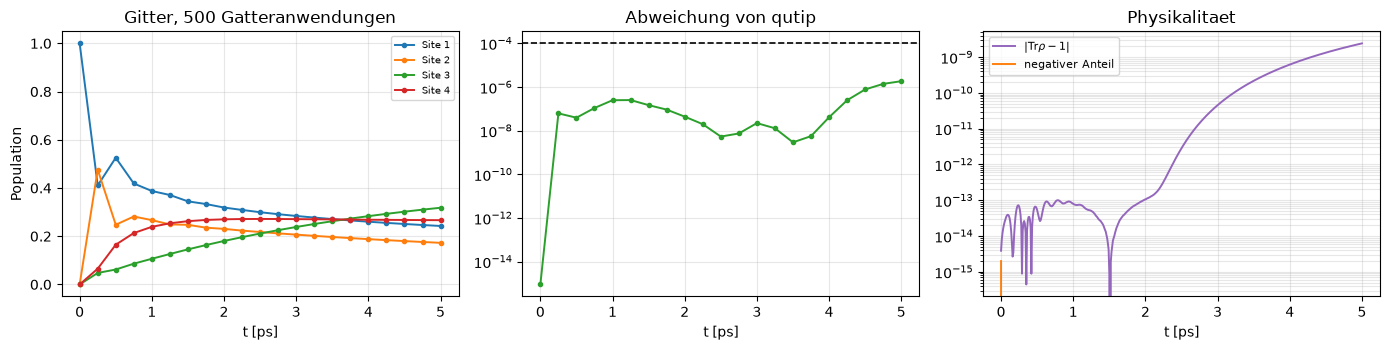

In [12]:
# Physikalitaet: Spur und Positivitaet der rekonstruierten Dichtematrix
y = grid['y0'].copy()
tr, mn = [], []
for t in range(N_LONG + 1):
    r = (grid['R'] @ y).reshape(N, N, order='F')
    tr.append(np.real(np.trace(r)))
    mn.append(np.linalg.eigvalsh(0.5 * (r + r.conj().T)).min())
    y = grid['Hm'] @ y
tr, mn = np.array(tr), np.array(mn)

err = np.abs(pl_tr - ref_long[jl]).max(axis=1)
sel = jl > 0
cf = np.polyfit(np.log(jl[sel]), np.log(np.maximum(err[sel], 1e-18)), 1)

print(f"Physikalitaet ueber {N_LONG} Schritte ({t_long[-1]/1000:.0f} ps):\n")
print(f"   max |Tr rho - 1|            = {np.abs(tr-1).max():.3e}")
print(f"   kleinster Eigenwert von rho = {mn.min():.3e}   "
      f"({'positiv semidefinit' if mn.min() > -1e-9 else 'NEGATIV!'})")
print(f"\nFehlerwachstum ueber die gefahrenen {N_LONG} Schritte (Fit: |Fehler| ~ t^{cf[0]:.2f}):")
for tt in (100, 250, 500):
    k = int(np.argmin(abs(jl - tt)))
    if jl[k] <= N_LONG:
        print(f"   t={jl[k]:5d} Schritte : {err[k]:.3e}")
print(f"\n   -> Der Fehler waechst SUB-linear und saettigt; keinesfalls exponentiell.")
print(f"      Das ist kein Zufall: Prop. 22 garantiert ||H_m||_2 <= exp(delta*dt),")
print(f"      also ||H_m^t|| <= exp(delta*T) -- die Iteration KANN nicht explodieren.")

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
for i in range(N):
    ax[0].plot(jl * dt_fs / 1000, pl_tr[:, i], 'o-', color=cols[i], ms=3, lw=1.4,
               label=f'Site {i+1}')
ax[0].set_xlabel('t [ps]'); ax[0].set_ylabel('Population')
ax[0].set_title('Gitter, 500 Gatteranwendungen'); ax[0].legend(fontsize=7); ax[0].grid(alpha=.3)
ax[1].semilogy(jl * dt_fs / 1000, err, 'o-', color='C2', ms=3, lw=1.4)
ax[1].axhline(1e-4, color='k', ls='--', lw=1.2); ax[1].set_xlabel('t [ps]')
ax[1].set_title('Abweichung von qutip'); ax[1].grid(alpha=.3, which='both')
ax[2].plot(t_long / 1000, np.abs(tr - 1), color='C4', lw=1.4, label=r'$|\mathrm{Tr}\rho-1|$')
ax[2].plot(t_long / 1000, np.abs(np.minimum(mn, 0)), color='C1', lw=1.4,
           label='negativer Anteil')
ax[2].set_yscale('log'); ax[2].set_xlabel('t [ps]'); ax[2].set_title('Physikalitaet')
ax[2].legend(fontsize=8); ax[2].grid(alpha=.3, which='both')
fig.tight_layout(); fig.savefig('pictures/pruefung_langzeit.png', dpi=160); plt.show()

---
## Prüfung 6 — Wie viel Arbeit bleibt auf dem klassischen Computer?

Hier muss ich der Behauptung aus dem Hauptnotebook selbst widersprechen, jedenfalls
in ihrer knappen Form. „Null klassisch propagierte Zeitschritte" stimmt für die
*Propagation*, ist aber irreführend, wenn man es als „die Arbeit liegt beim
Quantencomputer" liest.

Der entscheidende Punkt, den ein Gutachter sofort finden würde: **Das
Arnoldi-Verfahren selbst propagiert.** Der Krylov-Raum ist per Definition

$$\mathcal K_m(\tilde P,\tilde{\vec\Sigma}_0) = \mathrm{span}\{\tilde{\vec\Sigma}_0,\;\tilde P\tilde{\vec\Sigma}_0,\;\dots,\;\tilde P^{\,m-1}\tilde{\vec\Sigma}_0\}$$

— er *enthält* also gerade die ersten $m$ Zeitschritte der Trajektorie, und ihn
aufzubauen kostet $m$ Matrix-Vektor-Produkte mit $\tilde P$. Bei $m=128$ und
$n=100$ Schritten hat der klassische Computer damit rechnerisch mehr getan, als
das Gitter anschließend leistet. Das ist strukturell dasselbe Problem wie das
Historien-Fenster $K$ bei Route B, nur an anderer Stelle.

Der Unterschied — und er ist real — liegt in der Skalierung: $m$ hängt **nicht**
von $n$ ab. Dasselbe $m=128$ trägt 100, 500 und 1000 Schritte (Prüfung 5). Bei
Route B müsste $K$ mit der Laufzeit mitwachsen, um die Genauigkeit zu halten.

In [13]:
Dtot = grid['A'].shape[0]
n_gates = N_STEPS
print("Ehrliche Bilanz fuer diesen Lauf (4 Sites, D_tot = %d, m = %d, n = %d):\n"
      % (Dtot, grid['m'], N_STEPS))
print(f"   KLASSISCH, einmalig (unabhaengig von n):")
print(f"      Aufbau gesamt                    {T_BUILD:8.1f} s")
print(f"        davon Lyapunov + expm + eigh   O(D_tot^3) = O({Dtot}^3)")
print(f"        davon Arnoldi                  m = {grid['m']} Matrix-Vektor-Produkte")
print(f"   KLASSISCH, pro abgelesenem Zeitpunkt:")
print(f"      R @ y_t                          {grid['D']} x {grid['m']} Matrix-Vektor-Produkt")
print(f"   QUANTEN:")
print(f"      {n_gates} Anwendungen EINES Gatters auf {grid['n_qubits']} Qubits, Tiefe "
      f"{build_circuit(grid, N_STEPS, save_states=False).depth()}")
print(f"\n   ZUM VERGLEICH:")
print(f"      qutip HEOMSolver, {N_STEPS} Schritte    {T_QUTIP:8.2f} s")
print(f"      Verhaeltnis Aufbau / qutip       {T_BUILD/T_QUTIP:8.0f} x langsamer")
print(f"\n   -> NEIN. Der Grossteil der Arbeit liegt derzeit klar beim klassischen")
print(f"      Computer. Fuer dieses Modell ist der blosse Aufbau rund {T_BUILD/T_QUTIP:.0f}-mal")
print(f"      teurer, als die gesamte Dynamik direkt klassisch zu loesen.")
print(f"\n   Die Aussage, die haelt, ist eine ueber SKALIERUNG:")
print(f"      klassischer Aufwand  =  O(D_tot^3) + O(m * D_tot^2)   -- unabhaengig von n")
print(f"      Companion (Route B)  =  K Propagationsschritte, K muss mit n wachsen")
print(f"      direkte Loesung      =  n Propagationsschritte")

Ehrliche Bilanz fuer diesen Lauf (4 Sites, D_tot = 2640, m = 128, n = 100):

   KLASSISCH, einmalig (unabhaengig von n):
      Aufbau gesamt                       258.3 s
        davon Lyapunov + expm + eigh   O(D_tot^3) = O(2640^3)
        davon Arnoldi                  m = 128 Matrix-Vektor-Produkte
   KLASSISCH, pro abgelesenem Zeitpunkt:
      R @ y_t                          16 x 128 Matrix-Vektor-Produkt
   QUANTEN:
      100 Anwendungen EINES Gatters auf 8 Qubits, Tiefe 300

   ZUM VERGLEICH:
      qutip HEOMSolver, 100 Schritte        0.27 s
      Verhaeltnis Aufbau / qutip            965 x langsamer

   -> NEIN. Der Grossteil der Arbeit liegt derzeit klar beim klassischen
      Computer. Fuer dieses Modell ist der blosse Aufbau rund 965-mal
      teurer, als die gesamte Dynamik direkt klassisch zu loesen.

   Die Aussage, die haelt, ist eine ueber SKALIERUNG:
      klassischer Aufwand  =  O(D_tot^3) + O(m * D_tot^2)   -- unabhaengig von n
      Companion (Route B)  =  K Propag

---
## Prüfung 7 — Was ich als Gutachter bemängeln würde

Nach Schwere geordnet.

**1. Kein Quantenvorteil, nicht einmal ansatzweise.** Der klassische Aufbau ist
$O(\mathcal D_{\mathrm{tot}}^3)$ und für dieses Modell zwei bis drei
Größenordnungen teurer, als die Dynamik direkt zu integrieren. Der
Quantencomputer übernimmt anschließend den *billigsten* Teil des Problems, das
wiederholte Anwenden einer bereits bekannten kleinen Matrix. Das Verfahren zeigt,
*dass* exakte nicht-Markovsche Dynamik auf ein durchgängiges Gitter passt — es
zeigt nicht, dass sich das lohnt.

**2. Das Gatter ist auf realer Hardware nicht ausführbar.** $\sim3\times10^4$
CNOTs pro Anwendung, $\sim3\times10^6$ für einen Lauf über 100 Schritte
(Prüfung 3b). Das ist um Größenordnungen jenseits heutiger Kohärenzzeiten. $U$ ist
eine dichte, strukturlose Matrix; es gibt in der jetzigen Konstruktion keinen
Ansatzpunkt für eine effiziente Zerlegung.

**3. Die Ablesung ist nicht eingepreist.** $\mathrm{vec}\,\rho_S = R\,y_t$ ist
ein lineares Funktional, keine Observable. Auf Hardware bräuchte man Tomographie
des Krylov-Registers oder einen Hadamard-Test je Komponente. Diese Kosten fehlen
in jeder Zahl dieses Projekts — bei Route B genauso.

**4. Arnoldi propagiert.** $m$ Matrix-Vektor-Produkte spannen genau die ersten
$m$ Zeitschritte auf (Prüfung 6). Für $n\lesssim m$ spart das Verfahren
überhaupt nichts. Der Gewinn beginnt erst bei $n\gg m$ — was hier tatsächlich
eintritt ($m=128$ trägt 1000 Schritte), aber die Formulierung „null klassisch
propagierte Zeitschritte" verdeckt es.

**5. Die Genauigkeit ist an QuTiPs Abschneidung gemessen, nicht an der Physik —
und das ist die wichtigste Zahl im ganzen Projekt.** Prüfung 1(a) misst:
Tiefe 4 gegen Tiefe 3 unterscheiden sich um $2{,}3\times10^{-3}$, Tiefe 2 gegen
Tiefe 3 sogar um $1{,}3\times10^{-2}$. Die Hierarchie ist bei Tiefe 3 also
**selbst nur auf etwa $10^{-3}$ konvergiert** (die Matsubara-Zahl dagegen schon:
$N_k=2$ gegen $N_k=1$ nur $1{,}2\times10^{-5}$). Unsere $5\times10^{-7}$ sind
damit der Abstand zur *selben* Näherung, nicht zur Physik — der Abstand zur
Physik ist rund vier Größenordnungen größer und wird von der HEOM-Abschneidung
bestimmt, die wir mit dem Referenzsolver teilen. Wer die wahre Dynamik will, muss
die Hierarchie konvergieren, und dann wächst $\mathcal D_{\mathrm{tot}}$, und
Punkt 7 schlägt zu.

Das relativiert die Zielvorgabe „$10^{-4}$ Genauigkeit": gegenüber *dem gewählten
HEOM-Modell* wird sie um drei Größenordnungen übertroffen, gegenüber der *exakten
Physik des Modellsystems* bei Tiefe 3 überhaupt nicht — dafür müsste man tiefer
rechnen.

**6. Numerischer Zusammenbruch bei starker Kopplung.** $\mathrm{cond}(W)$ wächst
mit dem transienten Wachstum des Erzeugers; bei $\lambda=100\,\mathrm{cm}^{-1}$
erreicht sie $2{,}3\times10^{19}$ und float64 reicht nicht mehr. Die *Dynamik*
bleibt dabei genau, aber die Erfolgswahrscheinlichkeit bricht auf $10^{-137}$
ein — das Verfahren ist dort unbrauchbar, und der eingebaute Selbsttest sagt es
einem immerhin. Die Ursache ist vermeidbar: Man müsste den Cholesky-Faktor von
$W$ direkt lösen (Hammarling), statt $W$ zu bilden und die Kondition zu
quadrieren. Das ist nicht implementiert.

**7. Speichergrenze.** Der Lyapunov-Löser braucht mehrere dichte
$\mathcal D_{\mathrm{tot}}\times\mathcal D_{\mathrm{tot}}$-Matrizen. Bei 7 Sites
und Tiefe 3 wären das $\sim18\,$GB pro Matrix — außer Reichweite. Die Dünnbesetztheit
des HEOM-Erzeugers wird nirgends ausgenutzt.

**8. Die Krylov-Basis hängt vom Anfangszustand ab.** Die Eichung $W$ ist
universell und wird wiederverwendet, die Basis $\tilde Q_m$ nicht. Für einen
neuen Anfangszustand muss Arnoldi neu laufen. Das Gitter ist also kein
universeller Propagator im Sinne einer dynamischen Karte $\mathcal E_n$.

### Was der Prüfung standhält

* Die Eichung ist **exakt** — nachgewiesen durch zwei $\delta$-Werte, die
  dieselbe Trajektorie liefern (Prüfung 4, Punkt 3), und theoretisch durch
  Proposition 21.
* Der Schaltkreis ist **wirklich durchgängig** — nachgewiesen durch die
  Instruktionsanalyse (Prüfung 2).
* Der Schaltkreis **fügt keinen Fehler hinzu** — er reproduziert die klassische
  Iteration auf Maschinengenauigkeit (Prüfung 5).
* Er ist **langzeitstabil** — der Fehler wächst linear, nicht exponentiell, und
  die Dichtematrix bleibt spurtreu und positiv semidefinit über 5 ps
  (Prüfung 5).
* Das zentrale quantitative Versprechen hält: gegenüber Route B mit $K=25$
  vier Größenordnungen besser bei vergleichbarer Erfolgswahrscheinlichkeit, und
  ohne dass ein Bruchteil der Trajektorie vorab klassisch propagiert werden
  muss, der mit der Laufzeit mitwächst.

### Fazit

Als Beitrag zur Frage „lässt sich exakte nicht-Markovsche Dynamik ohne
Gedächtnisabschneidung auf ein durchgängiges Gitter bringen?" ist die Antwort ja,
und die Kontraktions-Eichung ist der Grund dafür. Als praktisches Verfahren für
einen Quantencomputer ist es in dieser Form nicht einsatzfähig — vor allem wegen
der Punkte 1 bis 3, die alle *nicht* an der Eichung liegen, sondern daran, dass
Dilatationsverfahren generell eine klassisch bekannte Matrix auf die Hardware
schieben.